## Import packages

Our first step will be to ipmport in our libraries. In addition to our standard `numpy`, `pandas`, and `matplotlib` libraries, we also are brining in the `curve_fit` function from `scipy`!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

## Define variables

Below, we define some basic parameters, such as our pKa values, acid and base concentrations, and acid volumes. We also define a list of 80 numbers between 0 and 100 describing the volume of base added

In [2]:
# Random seed for reproducibility
np.random.seed(42)

# True experimental parameters
true_pKa = 4.75 #pKa
true_Ca = 0.100   # mol/L acid
true_Cb = 0.100   # mol/L NaOH
true_Va = 50.0    # mL acid

# Volumes of NaOH added
Vb = np.linspace(0, 100, 80)  # mL


## Define a function to model titration
Next, we define a simple function which allows us to approximate a monoprotic acid titration curve. Given a list of base volumes, a pKa value, and concentrations of the base and acid, this function will return a list of values corresponding with the pH at each increment in the base volume added list.

In [3]:
#function to model titration
def titration_model(Vb, pKa, Ca, Cb):
    """
    Approximate monoprotic acid titration curve.
    Vb is NaOH volume added in mL.
    """

    Va = true_Va

    # convert mL to L
    acid_moles = Ca * Va / 1000
    base_moles = Cb * Vb / 1000

    Veq = acid_moles / Cb * 1000  # equivalence volume in mL

    pH = np.zeros_like(Vb)

    for i, V in enumerate(Vb):

        total_volume = (Va + V) / 1000

        if V == 0:
            # weak acid approximation
            H = np.sqrt(10**(-pKa) * Ca)
            pH[i] = -np.log10(H)

        elif V < Veq:
            # buffer region
            HA = acid_moles - base_moles[i]
            A = base_moles[i]

            pH[i] = pKa + np.log10(A / HA)

        elif np.isclose(V, Veq):
            # equivalence point
            Kb = 10**(-(14-pKa))
            Csalt = acid_moles / total_volume

            OH = np.sqrt(Kb * Csalt)
            pH[i] = 14 + np.log10(OH)

        else:
            # excess strong base
            OH = (base_moles[i] - acid_moles) / total_volume
            pH[i] = 14 + np.log10(OH)

    return pH

## Calculate pH values for our list of base volumes
Using the function we define above, let's calculate the appropriate pH values for our parameters!

We also go through the effort of simulating some experimental noise as well by drawing from a normal distribution, and combine this experimental noise with our true pH values to simulate our dataset.

In [4]:
# Generate ideal data
pH_true = titration_model(
    Vb,
    true_pKa,
    true_Ca,
    true_Cb
)

# Add experimental noise
noise = np.random.normal(
    loc=0,
    scale=0.04,
    size=len(Vb)
)

#add noise to true pH values
pH_noisy = pH_true + noise

#print out noisy pH
print(pH_noisy)

[ 2.89486857  3.1590087   3.50290627  3.72574958  3.7924655   3.90178543
  4.06627496  4.11391207  4.13600046  4.24164507  4.26164128  4.31791864
  4.39952704  4.36416627  4.42059114  4.51443367  4.54253888  4.6408363
  4.63651308  4.66050759  4.81962134  4.79601651  4.85208576  4.83725396
  4.91810423  4.99100891  4.98859984  5.09948167  5.11243464  5.17954095
  5.22532938  5.3860339   5.37954883  5.41329215  5.57401802  5.59202178
  5.770589    5.84187491  6.1005649   6.64996905 10.82814154 11.27715011
 11.48215647 11.61556995 11.67238516 11.78471221 11.86252169 11.98033004
 12.0011556  11.96025873 12.08232962 12.08864597 12.10841204 12.18865909
 12.23179637 12.25215109 12.20391187 12.24614224 12.29141765 12.33562019
 12.29476381 12.32284604 12.30146308 12.31249573 12.40672677 12.44167349
 12.39711301 12.4521244  12.43790184 12.40858749 12.45934154 12.51646974
 12.46317545 12.53647803 12.37803343 12.52429897 12.50319276 12.49574505
 12.51909329 12.44337599]


## Converting into a pandas dataframe
To make downstream plotting and manipulation a little easier, we'll convert our two lists, base volumes and their associated pH values, into a Pandas dataframe.

In [5]:
# Store as a pandas DataFrame
data = pd.DataFrame({
    "NaOH_added_mL": Vb,
    "pH_measured": pH_noisy
})

#print first 5 lines of dataframe
data.head()

,NaOH_added_mL,pH_measured
0,0.000000,2.894869
1,1.265823,3.159009
2,2.531646,3.502906
3,3.797468,3.725750
4,5.063291,3.792466


## Plotting our titration curve

Let's plot our simulated titration code below!

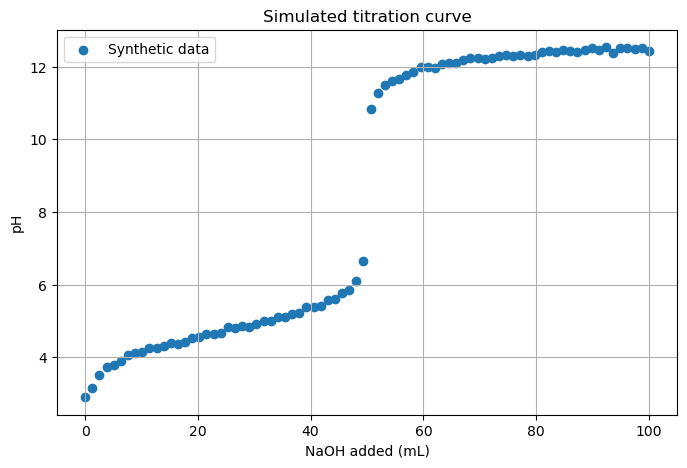

In [6]:
#set figure size
plt.figure(figsize=(8,5))

#scatterplot
plt.scatter(
    data["NaOH_added_mL"],
    data["pH_measured"],
    label="Synthetic data"
)

#axes labels
plt.xlabel("NaOH added (mL)")
plt.ylabel("pH")

#plot title, legend, and grid
plt.title("Simulated titration curve")
plt.legend()
plt.grid(True)

#show plot
plt.show()

## Fitting a curve to our data
Given a dataset of base volume added and pH, we can fit the function that we wrote to this data using the `curve_fit` function from `scipy`. There is some nuance to how we use this function, so let's talk through it!

`curve_fit` takes three basic positional arguments. The first argument supplied should be the function which we are fitting to the data, the second argument should represent the X axis/predictor/independent variable, and the third argument should be our Y axis/response/dependent variable. Our X axis variable should corespond with the first argument of our function (i.e. our `NaOH_added_mL` column from the dataframe corresponds with the `Vb` argument of the `titration_model` function), and our Y axis variable should correspond with the output of the function. `curve_fit` will produce estimates of the rest of the parameters of the function, with the option of providing a list of starting values, or initial guesses, for each of these parameters. 

The output of this will be a list containing the parameter estimates, as well as a nested list representing a variance-covariance matrix.

In [7]:
# Initial guesses for parameter estimates
initial_guess = [
    5.0,     # pKa
    0.08,    # Ca
    0.12     # Cb
]

#fit curve to estimate parameters
parameters, covariance = curve_fit(
    titration_model, # function describing titration model
    data["NaOH_added_mL"], # X axis/predictor/independent variable
    data["pH_measured"], # Y axis/response/dependent variable
    p0=initial_guess # starting parameter estimates
)

#assign estimated parameters to unique variables
fitted_pKa, fitted_Ca, fitted_Cb = parameters

# print estimates
print(f"Fitted pKa = {fitted_pKa:.3f}")
print(f"Fitted Ca  = {fitted_Ca:.4f} M")
print(f"Fitted Cb  = {fitted_Cb:.4f} M")

Fitted pKa = 4.740
Fitted Ca  = 0.0995 M
Fitted Cb  = 0.0995 M


## Plotting the fitted curve with our simulated data
Finally, we can generate the pH values associated with our list of base volumes and fitted parameters, and then plot that fitted curve alongside our scatterplot!

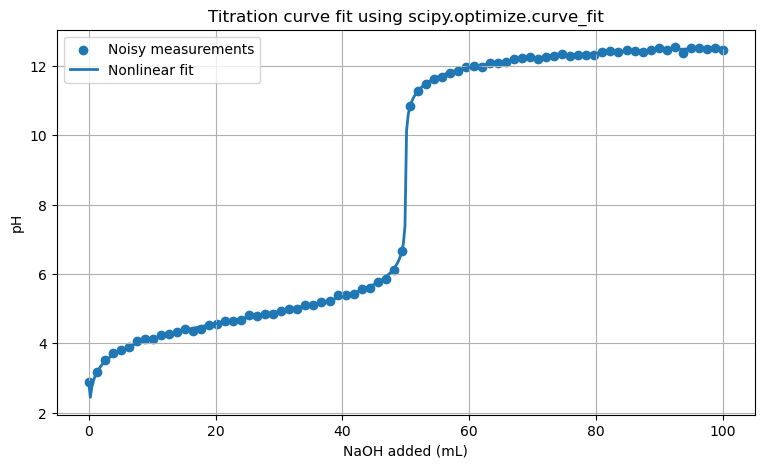

In [8]:
#generate 400 equally spaced numbers between 0 and 100
Vb_smooth = np.linspace(
    0,
    100,
    400
)

#supply smooth base volume and fitted parameter values to titration model
pH_fit = titration_model(
    Vb_smooth,
    fitted_pKa,
    fitted_Ca,
    fitted_Cb
)

#set figure size
plt.figure(figsize=(9,5))

# plot simulated data
plt.scatter(
    data["NaOH_added_mL"],
    data["pH_measured"],
    label="Noisy measurements"
)

# plot fitted curve
plt.plot(
    Vb_smooth,
    pH_fit,
    linewidth=2,
    label="Nonlinear fit"
)

#axes labels
plt.xlabel("NaOH added (mL)")
plt.ylabel("pH")

#title
plt.title("Titration curve fit using scipy.optimize.curve_fit")

#legend and grid
plt.legend()
plt.grid(True)

#show plot
plt.show()